# Agro Inteligente — SLCE3 Climate Impact Analysis

**Company:** SLC Agrícola (SLCE3) · **Period:** Jan–Jun 2025 · **Region:** Sorriso, MT  
**Authors:** Lucas Lellis Barros, Gabriel Pires Pinheiro Correa, Hannah Gabrielly Marques Pompeu

In [18]:
import openpyxl
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading

In [19]:
wb = openpyxl.load_workbook('dados.xlsx', read_only=True)
ws = wb.active

rows = list(ws.iter_rows(values_only=True))
df = pd.DataFrame(rows[1:], columns=rows[0])

df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data').reset_index(drop=True)

numeric_cols = [
    'preco_abertura', 'preco_maximo', 'preco_minimo', 'preco_fechamento',
    'volume', 'retorno_diario', 'media_movel_7d', 'temperatura_media',
    'temperatura_maxima', 'temperatura_minima', 'precipitacao_mm',
    'velocidade_vento', 'chuva_acumulada_7d', 'precipitacao_lag_7d'
]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

df.head()

,data,ano,semestre,mes,dia,estado,cidade,latitude,longitude,ticker,...,chuva_acumulada_7d,temperatura_media_7d,precipitacao_lag_7d,preco_abertura,preco_maximo,preco_minimo,preco_fechamento,volume,retorno_diario,media_movel_7d
0,2025-01-02,2025.0,1.0,1.0,2.0,MT,Sorriso,-12.5458,-55.7114,SLCE3,...,15.0,24.250000,NaN,15.555555,15.715555,15.351111,15.395555,2269800.0,NaN,15.395555
1,2025-01-03,2025.0,1.0,1.0,3.0,MT,Sorriso,-12.5458,-55.7114,SLCE3,...,15.2,24.666667,NaN,15.297777,15.360000,15.128888,15.128888,1986525.0,-0.017321,15.262221
2,2025-01-06,2025.0,1.0,1.0,6.0,MT,Sorriso,-12.5458,-55.7114,SLCE3,...,18.5,24.933333,NaN,15.146666,15.377777,15.120000,15.306666,2018137.0,0.011751,15.277036
3,2025-01-07,2025.0,1.0,1.0,7.0,MT,Sorriso,-12.5458,-55.7114,SLCE3,...,24.2,25.014286,NaN,15.306666,15.484444,15.200000,15.404444,2325375.0,0.006388,15.308888
4,2025-01-08,2025.0,1.0,1.0,8.0,MT,Sorriso,-12.5458,-55.7114,SLCE3,...,15.8,25.000000,11.6,15.404444,15.431111,15.226666,15.226666,1796062.0,-0.011541,15.292444


## 2. Derived Metrics

In [20]:
df['drawdown'] = ((df['preco_fechamento'] - df['preco_fechamento'].cummax()) / df['preco_fechamento'].cummax() * 100).round(4)
df['cumulative_return'] = ((1 + df['retorno_diario'].fillna(0)).cumprod() - 1) * 100
df['volatility_7d'] = df['retorno_diario'].rolling(7).std() * 100

month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun'}
df['month_name'] = df['mes'].map(month_map)

monthly = df.groupby('mes').agg(
    month_name=('month_name', 'first'),
    price_mean=('preco_fechamento', 'mean'),
    volume_total=('volume', 'sum'),
    return_mean=('retorno_diario', 'mean'),
    temp_mean=('temperatura_media', 'mean'),
    precip_mean=('precipitacao_mm', 'mean'),
    precip_total=('precipitacao_mm', 'sum'),
    drawdown_mean=('drawdown', 'mean')
).reset_index()

## 3. KPIs

In [21]:
kpis = {
    'Period':               f"{df['data'].min().strftime('%d/%m/%Y')} - {df['data'].max().strftime('%d/%m/%Y')}",
    'Trading days':         len(df),
    'Open price (R$)':      round(df.iloc[0]['preco_fechamento'], 2),
    'Close price (R$)':     round(df.iloc[-1]['preco_fechamento'], 2),
    'Total return (%)':     round(((df.iloc[-1]['preco_fechamento'] / df.iloc[0]['preco_fechamento']) - 1) * 100, 2),
    'Daily volatility (%)': round(df['retorno_diario'].std() * 100, 2),
    'Max drawdown (%)':     round(df['drawdown'].min(), 2),
    'Best day (%)':         round(df['retorno_diario'].max() * 100, 2),
    'Worst day (%)':        round(df['retorno_diario'].min() * 100, 2),
    'Avg temperature (C)':  round(df['temperatura_media'].mean(), 1),
    'Total rainfall (mm)':  round(df['precipitacao_mm'].sum(), 1),
}

pd.DataFrame(kpis.items(), columns=['KPI', 'Value'])

,KPI,Value
0,Period,02/01/2025 - 30/06/2025
1,Trading days,122
2,Open price (R$),15.4
3,Close price (R$),15.88
4,Total return (%),3.18
5,Daily volatility (%),1.69
6,Max drawdown (%),-14.55
7,Best day (%),8.11
8,Worst day (%),-3.94
9,Avg temperature (C),25.3


## 4. Pearson Correlations — Climate vs Market

In [22]:
climate_vars = {
    'temperatura_media':   'Avg Temperature',
    'temperatura_maxima':  'Max Temperature',
    'temperatura_minima':  'Min Temperature',
    'precipitacao_mm':     'Daily Rainfall',
    'chuva_acumulada_7d':  '7d Accumulated Rain',
    'precipitacao_lag_7d': 'Rainfall Lag 7d',
    'velocidade_vento':    'Wind Speed',
}

corr_results = []
for col, label in climate_vars.items():
    sub = df[[col, 'preco_fechamento', 'retorno_diario']].dropna()
    r_price,  p_price  = stats.pearsonr(sub[col], sub['preco_fechamento'])
    r_return, p_return = stats.pearsonr(sub[col], sub['retorno_diario'])
    abs_r = abs(r_price)
    strength = 'Negligible' if abs_r < 0.1 else 'Weak' if abs_r < 0.3 else 'Moderate' if abs_r < 0.5 else 'Strong'
    corr_results.append({
        'Variable':      label,
        'r (vs price)':  round(r_price, 4),
        'r (vs return)': round(r_return, 4),
        'p-value':       round(p_price, 4),
        'Strength':      strength,
        'Direction':     'Positive' if r_price > 0 else 'Negative'
    })

df_corr = pd.DataFrame(corr_results).sort_values('r (vs price)', key=abs, ascending=False)
df_corr

,Variable,r (vs price),r (vs return),p-value,Strength,Direction
1,Max Temperature,0.3499,-0.0770,0.0001,Moderate,Positive
0,Avg Temperature,0.3046,-0.0428,0.0007,Moderate,Positive
4,7d Accumulated Rain,-0.2512,0.2136,0.0054,Weak,Negative
3,Daily Rainfall,-0.2343,0.1548,0.0097,Weak,Negative
6,Wind Speed,-0.1026,0.0240,0.2629,Weak,Negative
5,Rainfall Lag 7d,-0.0529,0.0940,0.5694,Negligible,Negative
2,Min Temperature,0.0419,0.1137,0.6481,Negligible,Positive


## 5. Visualizations

### 5.1 Closing Price + 7d Moving Average

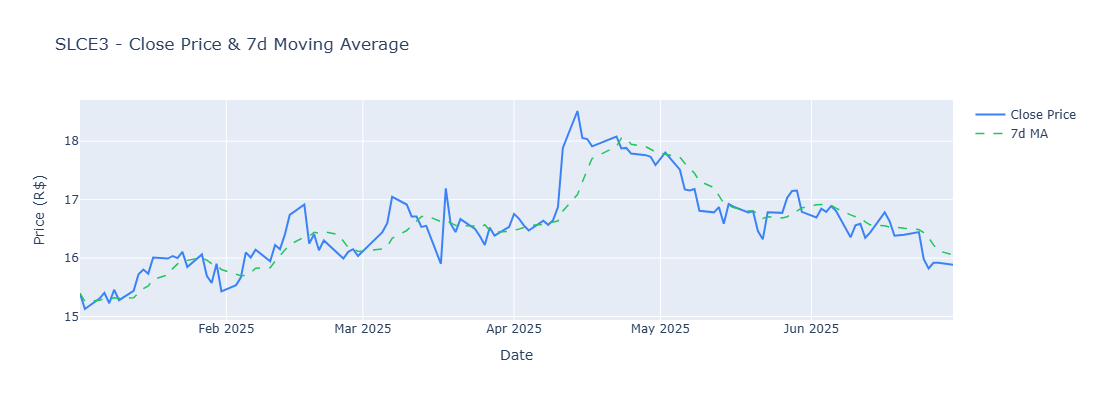

In [23]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=df['data'], y=df['preco_fechamento'], name='Close Price',
                         line=dict(color='#3b82f6', width=2)))
fig.add_trace(go.Scatter(x=df['data'], y=df['media_movel_7d'], name='7d MA',
                         line=dict(color='#22c55e', width=1.5, dash='dash')))
fig.update_layout(title='SLCE3 - Close Price & 7d Moving Average',
                  xaxis_title='Date', yaxis_title='Price (R$)',
                  height=400, hovermode='x unified')
fig.show()

### 5.2 Daily Return

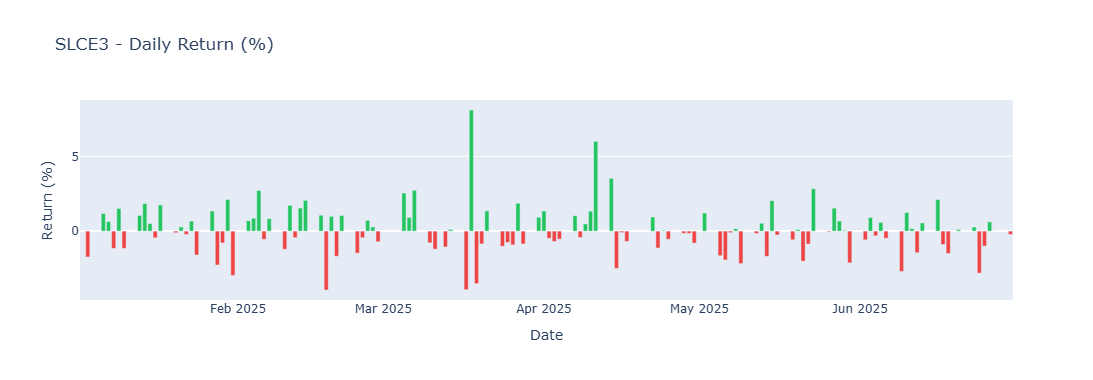

In [24]:
colors = ['#22c55e' if v >= 0 else '#ef4444' for v in df['retorno_diario'].fillna(0)]
fig = go.Figure(go.Bar(x=df['data'], y=df['retorno_diario'] * 100, marker_color=colors))
fig.update_layout(title='SLCE3 - Daily Return (%)',
                  xaxis_title='Date', yaxis_title='Return (%)', height=380)
fig.show()

### 5.3 Drawdown

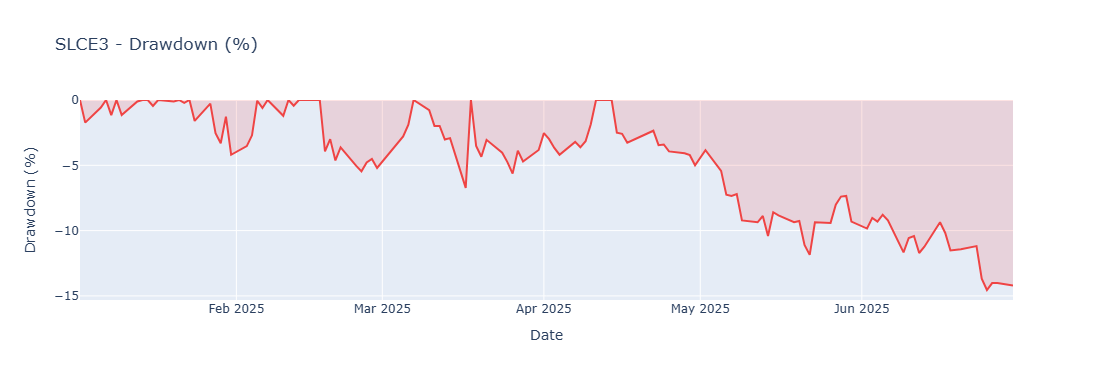

In [25]:
fig = go.Figure(go.Scatter(x=df['data'], y=df['drawdown'],
                           fill='tozeroy', mode='lines',
                           line=dict(color='#ef4444', width=2),
                           fillcolor='rgba(239,68,68,0.15)'))
fig.update_layout(title='SLCE3 - Drawdown (%)',
                  xaxis_title='Date', yaxis_title='Drawdown (%)', height=380)
fig.show()

### 5.4 Monthly Volume

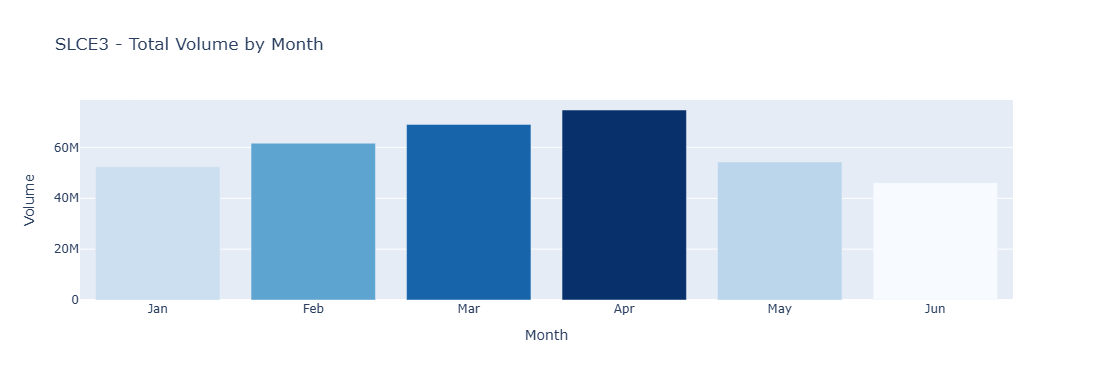

In [26]:
fig = px.bar(monthly, x='month_name', y='volume_total',
             title='SLCE3 - Total Volume by Month',
             labels={'month_name': 'Month', 'volume_total': 'Volume'},
             color='volume_total', color_continuous_scale='Blues')
fig.update_layout(height=380, coloraxis_showscale=False)
fig.show()

### 5.5 Rainfall vs Closing Price

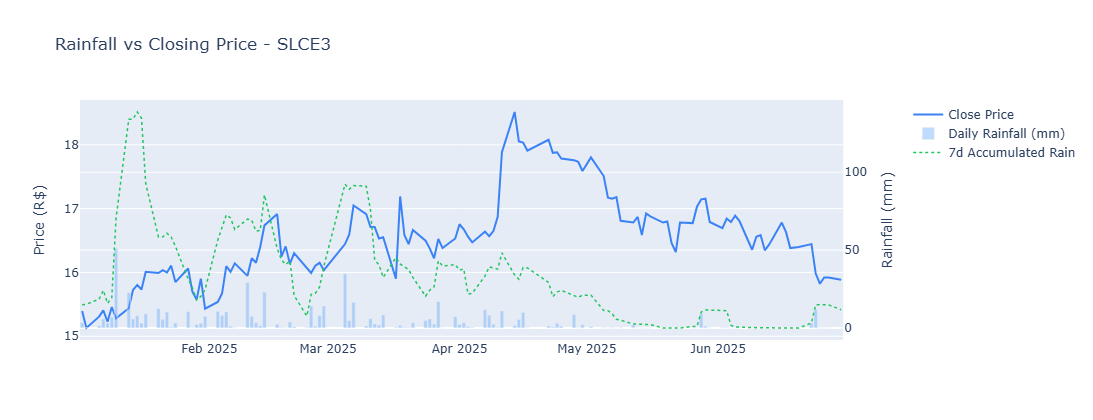

In [27]:
fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(go.Scatter(x=df['data'], y=df['preco_fechamento'], name='Close Price',
                         line=dict(color='#3b82f6', width=2)), secondary_y=False)
fig.add_trace(go.Bar(x=df['data'], y=df['precipitacao_mm'], name='Daily Rainfall (mm)',
                     marker_color='rgba(96,165,250,0.4)'), secondary_y=True)
fig.add_trace(go.Scatter(x=df['data'], y=df['chuva_acumulada_7d'], name='7d Accumulated Rain',
                         line=dict(color='#22c55e', width=1.5, dash='dot')), secondary_y=True)
fig.update_layout(title='Rainfall vs Closing Price - SLCE3', height=420, hovermode='x unified')
fig.update_yaxes(title_text='Price (R$)', secondary_y=False)
fig.update_yaxes(title_text='Rainfall (mm)', secondary_y=True)
fig.show()

### 5.6 Temperature vs Closing Price

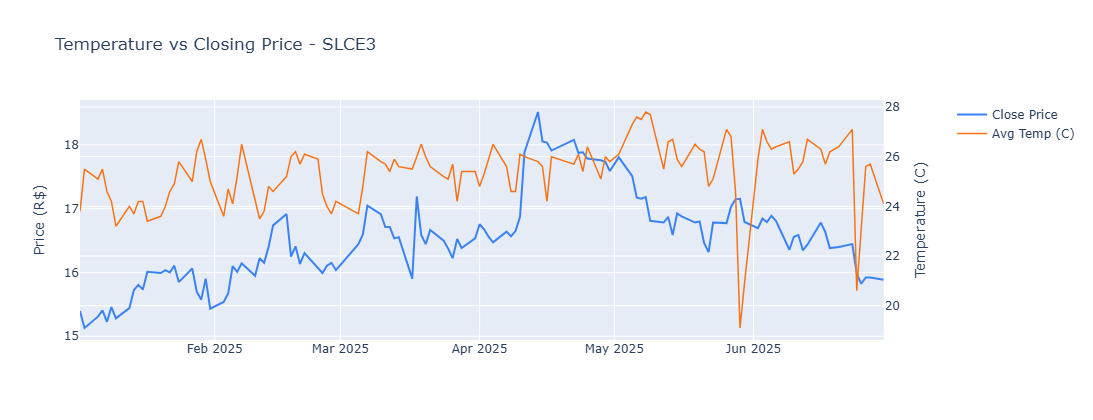

In [28]:
fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(go.Scatter(x=df['data'], y=df['preco_fechamento'], name='Close Price',
                         line=dict(color='#3b82f6', width=2)), secondary_y=False)
fig.add_trace(go.Scatter(x=df['data'], y=df['temperatura_media'], name='Avg Temp (C)',
                         line=dict(color='#f97316', width=1.5)), secondary_y=True)
fig.update_layout(title='Temperature vs Closing Price - SLCE3', height=420, hovermode='x unified')
fig.update_yaxes(title_text='Price (R$)', secondary_y=False)
fig.update_yaxes(title_text='Temperature (C)', secondary_y=True)
fig.show()

### 5.7 Scatter — Temperature x Price

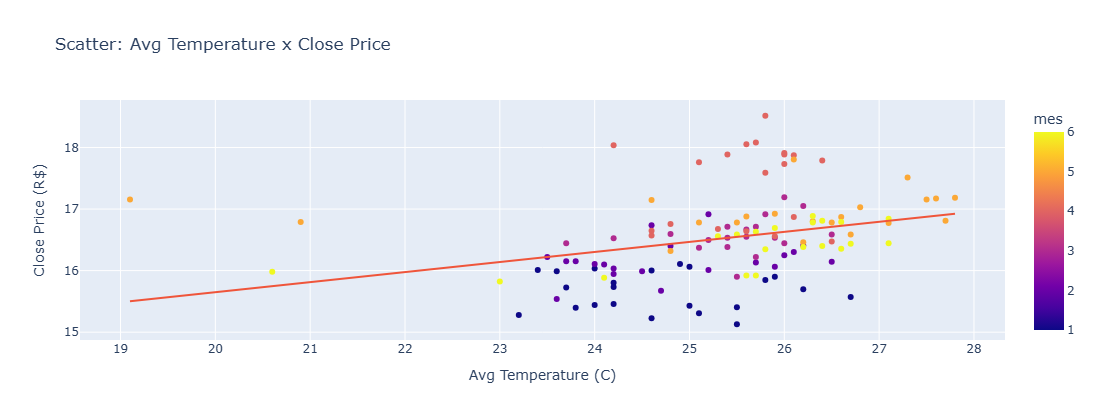

In [29]:
fig = px.scatter(df, x='temperatura_media', y='preco_fechamento',
                 trendline='ols', color='mes', hover_data=['data'],
                 labels={'temperatura_media': 'Avg Temperature (C)',
                         'preco_fechamento': 'Close Price (R$)'},
                 title='Scatter: Avg Temperature x Close Price')
fig.update_layout(height=420)
fig.show()

### 5.8 Scatter — Rainfall x Price

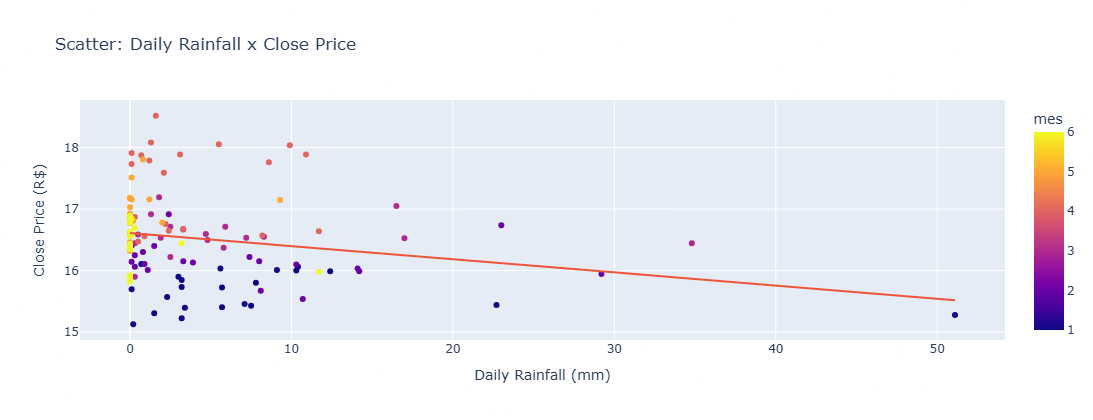

In [30]:
fig = px.scatter(df, x='precipitacao_mm', y='preco_fechamento',
                 trendline='ols', color='mes', hover_data=['data'],
                 labels={'precipitacao_mm': 'Daily Rainfall (mm)',
                         'preco_fechamento': 'Close Price (R$)'},
                 title='Scatter: Daily Rainfall x Close Price')
fig.update_layout(height=420)
fig.show()

### 5.9 Pearson Correlations — Bar Chart

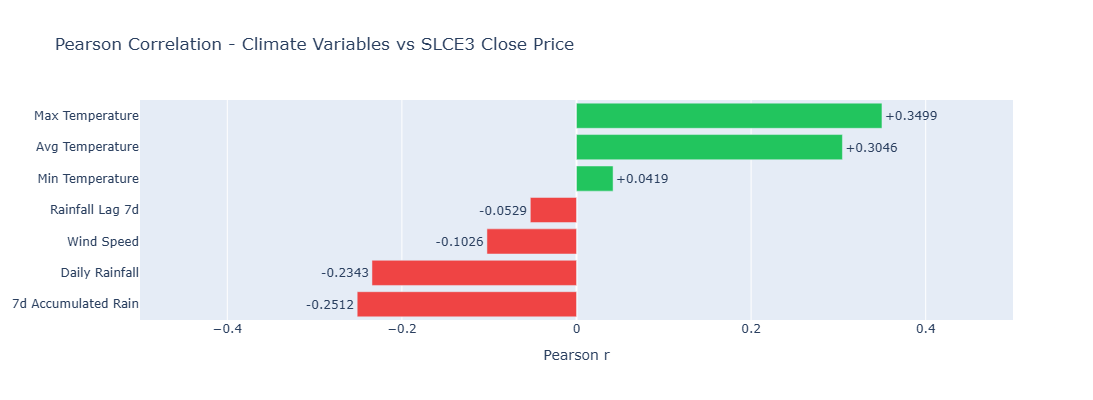

In [31]:
df_corr_sorted = df_corr.sort_values('r (vs price)')
bar_colors = ['#ef4444' if v < 0 else '#22c55e' for v in df_corr_sorted['r (vs price)']]

fig = go.Figure(go.Bar(
    x=df_corr_sorted['r (vs price)'],
    y=df_corr_sorted['Variable'],
    orientation='h',
    marker_color=bar_colors,
    text=df_corr_sorted['r (vs price)'].apply(lambda x: f'{x:+.4f}'),
    textposition='outside'
))
fig.update_layout(title='Pearson Correlation - Climate Variables vs SLCE3 Close Price',
                  xaxis_title='Pearson r', height=400, xaxis=dict(range=[-0.5, 0.5]))
fig.show()

### 5.10 Volatility 7d vs Accumulated Rain

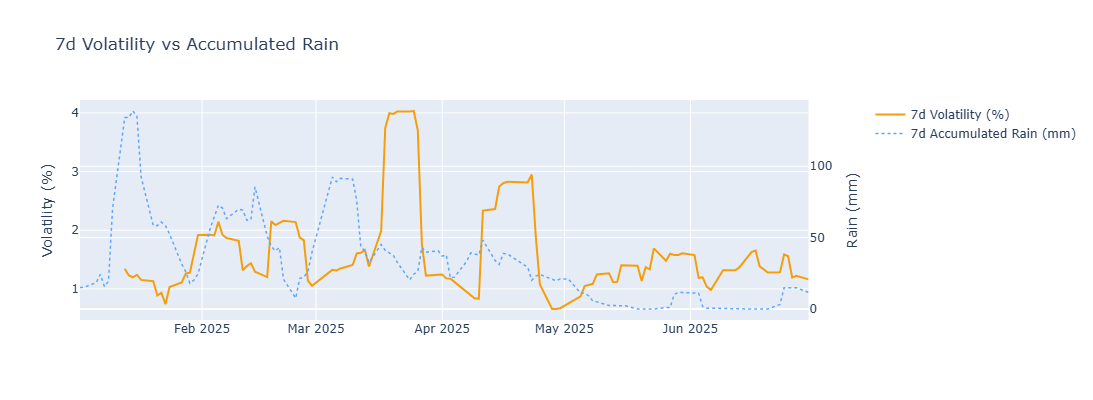

In [32]:
fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(go.Scatter(x=df['data'], y=df['volatility_7d'], name='7d Volatility (%)',
                         line=dict(color='#f59e0b', width=2)), secondary_y=False)
fig.add_trace(go.Scatter(x=df['data'], y=df['chuva_acumulada_7d'], name='7d Accumulated Rain (mm)',
                         line=dict(color='#60a5fa', width=1.5, dash='dot')), secondary_y=True)
fig.update_layout(title='7d Volatility vs Accumulated Rain', height=400, hovermode='x unified')
fig.update_yaxes(title_text='Volatility (%)', secondary_y=False)
fig.update_yaxes(title_text='Rain (mm)', secondary_y=True)
fig.show()

### 5.11 Monthly Summary

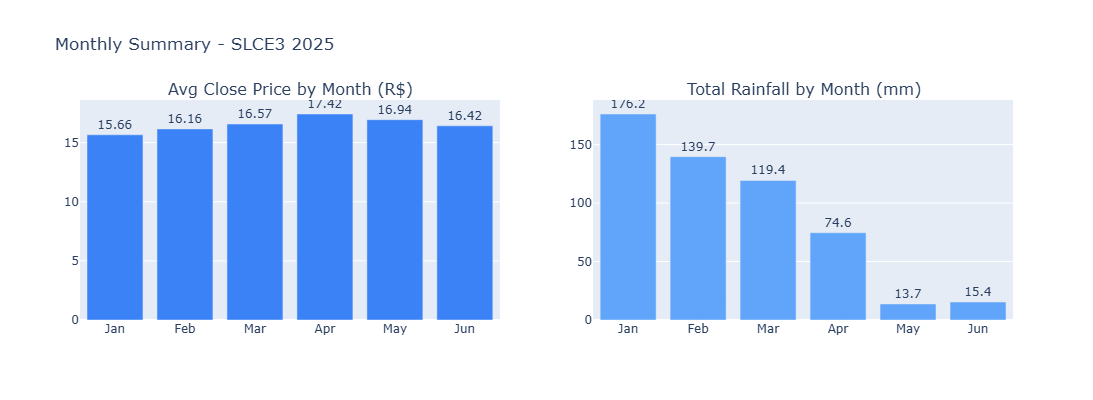

In [33]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Avg Close Price by Month (R$)', 'Total Rainfall by Month (mm)'))
fig.add_trace(go.Bar(x=monthly['month_name'], y=monthly['price_mean'].round(2),
                     marker_color='#3b82f6', text=monthly['price_mean'].round(2),
                     textposition='outside'), row=1, col=1)
fig.add_trace(go.Bar(x=monthly['month_name'], y=monthly['precip_total'].round(1),
                     marker_color='#60a5fa', text=monthly['precip_total'].round(1),
                     textposition='outside'), row=1, col=2)
fig.update_layout(height=400, showlegend=False, title='Monthly Summary - SLCE3 2025')
fig.show()

## 6. Conclusions

In [34]:
top     = df_corr.iloc[0]
r_rain  = df_corr[df_corr['Variable'] == 'Daily Rainfall']['r (vs price)'].values[0]
r_lag   = df_corr[df_corr['Variable'] == 'Rainfall Lag 7d']['r (vs price)'].values[0]
dd_jun  = monthly[monthly['mes'] == 6]['drawdown_mean'].values[0]

conclusions = {
    'Strongest climate correlation': f"{top['Variable']} (r={top['r (vs price)']}) - {top['Strength']} {top['Direction']}",
    'Rainfall vs price':             f"r={r_rain} (Weak Negative) - heavy rain slightly coincides with price drops",
    'Lag effect (7d)':               f"r={r_lag} (Negligible) - climate impact is immediate, not delayed",
    'Drought & drawdown':            f"May-Jun near-zero rainfall; Jun avg drawdown={dd_jun:.1f}% (worst of semester)",
    'Total return':                  f"{kpis['Total return (%)']:+.2f}%",
    'Max drawdown':                  f"{kpis['Max drawdown (%)']}%",
    'Daily volatility':              f"{kpis['Daily volatility (%)']}%",
}

pd.DataFrame(conclusions.items(), columns=['Topic', 'Finding'])

,Topic,Finding
0,Strongest climate correlation,Max Temperature (r=0.3499) - Moderate Positive
1,Rainfall vs price,r=-0.2343 (Weak Negative) - heavy rain slightl...
2,Lag effect (7d),r=-0.0529 (Negligible) - climate impact is imm...
3,Drought & drawdown,May-Jun near-zero rainfall; Jun avg drawdown=-...
4,Total return,+3.18%
5,Max drawdown,-14.55%
6,Daily volatility,1.69%
